In [5]:
# ---------- Setup ----------
%load_ext autoreload
%autoreload 2
import sys, os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Verify that SimpleArm is in the path
SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
if SIMPLEARM_PATH not in sys.path:
    sys.path.insert(0, SIMPLEARM_PATH)

from simplearm.robot import RobotInfo

# Import local functions
import models
from data import generate_dataset, print_dataset_stats, browse_dataset, visualize_environment
from losses import compute_trajectory_collision_cost, compute_trajectory_joint_limits_cost
from utils import get_world_spheres_torch, query_sdf_differentiable
from training import train, train_env_autoencoder, train_state_autoencoder
from visualization import browse_trajectories

# Robot configuration
WORKSPACE_RADIUS = 1.0
LINK_LENGTHS = [0.35, 0.45, 0.2]
SPHERE_RAD = 0.08
GRID_LENGTH = 2.5
N_VOX = 128
T = 50  # Time steps in the trajectory
C = 10  # Control points in the spline
Q_MIN = np.array([-np.pi*0.9, -np.pi*0.9, -np.pi*0.9])
Q_MAX = np.array([np.pi*0.9, np.pi*0.9, np.pi*0.9])

robot = RobotInfo.from_linklengths(LINK_LENGTHS, sphere_rad=SPHERE_RAD)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setup done. Executed in: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup done. Executed in: cuda


Generating SDFs...


Generating SDF dataset: 100%|██████████| 20000/20000 [00:25<00:00, 784.93it/s]


SDF dataset saved: data/sdf_dataset_overfit_v2.pt  shape=(20000, 1, 128, 128)


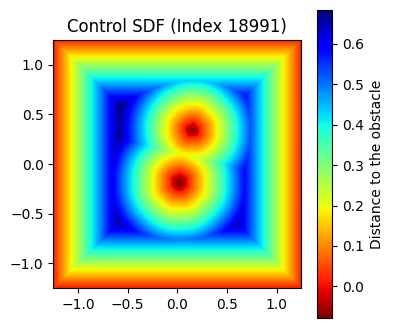

In [4]:
# ---------- SDF Dataset ----------
from data import generate_sdf_dataset

# Generate 20,000 environments for training the Autoencoder 
print("Generating SDFs...")
sdf_dataset = generate_sdf_dataset(N=20000, save_path="data/sdf_dataset_overfit_v2.pt", seed=42)

# Visual control
idx = torch.randint(0, len(sdf_dataset), (1,)).item()
plt.figure(figsize=(4, 4))
plt.imshow(sdf_dataset[idx, 0].cpu().numpy(), cmap="jet_r", origin="lower", 
           extent=[-GRID_LENGTH/2, GRID_LENGTH/2, -GRID_LENGTH/2, GRID_LENGTH/2])
plt.title(f"Control SDF (Index {idx})")
plt.colorbar(label="Distance to the obstacle")
plt.show()

Training the Environment Autoencoder...


Training Env Autoencoder: 100%|██████████| 8000/8000 [03:24<00:00, 39.07it/s]


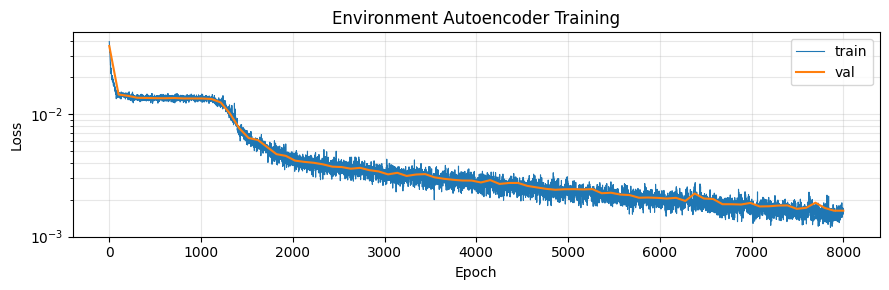

Test loss: 0.001806
Saved: data/env_autoencoder_overfit_v2.pt  (encoder -> data\env_encoder_overfit_v2.pt)
Weights saved in 'data/env_autoencoder_overfit_v2.pt'


In [2]:
# ---------- Environment Autoencoder Training ----------
print("Training the Environment Autoencoder...")

env_model, env_history = train_env_autoencoder(
    dataset_path = "data/sdf_dataset_overfit_v2.pt",
    file_name = "env_encoder_overfit_v2.pt",
    latent_dim   = 64,
    batch_size   = 128,                           
    epochs       = 8000,                          
    lr           = 1e-3,
    log_every    = 100,
    device       = device,
    save_path    = "data/env_autoencoder_overfit_v2.pt" 
)

print("Weights saved in 'data/env_autoencoder_overfit_v2.pt'")

Training State Autoencoder: 100%|██████████| 8000/8000 [00:21<00:00, 380.45it/s]


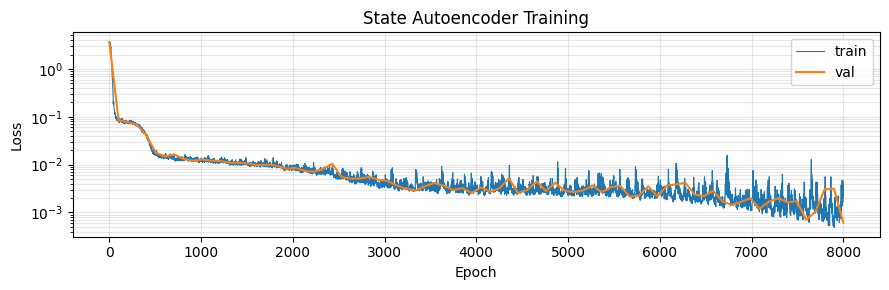

Test loss: 0.003382
Saved: data/state_autoencoder_overfit_v2.pt  (encoder -> data\state_encoder_overfit_v2.pt)
Weights saved in 'data/state_autoencoder_overfit_v2.pt'


In [ ]:
# ---------- State Autoencoder Training ----------
from training import train_state_autoencoder
state_ae, state_ae_history = train_state_autoencoder(
    file_name   = "state_encoder_overfit_v2.pt",
    linklengths = LINK_LENGTHS,
    dof         = 3,
    latent_dim  = 64,
    N           = 240_000,
    batch_size  = 128,
    epochs      = 8000,
    lr          = 1e-3,
    log_every   = 100,
    device      = device,
    save_path   = "data/state_autoencoder_overfit_v2.pt"
)

print("Weights saved in 'data/state_autoencoder_overfit_v2.pt'")

In [6]:
# ---------- Datasets generation ----------
SEED = 42

# General Dataset
dataset_overfit_v2_general = generate_dataset(
        N_envs            = 1000,
        pairs_per_env     = 10,
        robot             = robot,
        sphere_rad        = SPHERE_RAD,
        q_min             = Q_MIN,
        q_max             = Q_MAX,
        n_obstacles_range = (1, 3),
        r_range           = (0.06, 0.18),
        workspace_radius  = WORKSPACE_RADIUS,
        dist_from_origin  = (0.5, WORKSPACE_RADIUS),
        require_nontrivial= True,
        grid_length       = GRID_LENGTH,
        n_vox             = N_VOX,
        seed              = SEED,
        save_path         = "data/dataset_overfit_v2_general.pt",
        split             = (0.7, 0.15, 0.15)
        )

# 1 sample Dataset
dataset_overfit_v2_1_sample = generate_dataset(
            N_envs            = 1,
            pairs_per_env     = 1,
            robot             = robot,
            sphere_rad        = SPHERE_RAD,
            q_min             = Q_MIN,
            q_max             = Q_MAX,
            n_obstacles_range = (1, 1),
            r_range           = (0.1, 0.18),
            workspace_radius  = WORKSPACE_RADIUS,
            dist_from_origin  = (0.5, WORKSPACE_RADIUS),
            require_nontrivial= True,
            grid_length       = GRID_LENGTH,
            n_vox             = N_VOX,
            seed              = 6,
            save_path         = "data/dataset_overfit_v2_1_sample.pt"
        )

# 10 samples Dataset
dataset_overfit_v2_10_samples = generate_dataset(
            N_envs            = 1,
            pairs_per_env     = 10,
            robot             = robot,
            sphere_rad        = SPHERE_RAD,
            q_min             = Q_MIN,
            q_max             = Q_MAX,
            n_obstacles_range = (1, 1),
            r_range           = (0.1, 0.18),
            workspace_radius  = WORKSPACE_RADIUS,
            dist_from_origin  = (0.5, WORKSPACE_RADIUS),
            require_nontrivial= True,
            grid_length       = GRID_LENGTH,
            n_vox             = N_VOX,
            seed              = 6,
            save_path         = "data/dataset_overfit_v2_10_samples.pt"
        )

# 640 samples Dataset
dataset_overfit_v2_640_samples = generate_dataset(
            N_envs            = 64,
            pairs_per_env     = 10,
            robot             = robot,
            sphere_rad        = SPHERE_RAD,
            q_min             = Q_MIN,
            q_max             = Q_MAX,
            n_obstacles_range = (1, 2),
            r_range           = (0.06, 0.18),
            workspace_radius  = WORKSPACE_RADIUS,
            dist_from_origin = (0.4, WORKSPACE_RADIUS),
            require_nontrivial= True,
            grid_length       = GRID_LENGTH,
            n_vox             = N_VOX,
            seed              = 6,
            save_path         = "data/dataset_overfit_v2_640_samples.pt"
        )
    
# 5000 samples Dataset
dataset_overfit_v2_5000_samples = generate_dataset(
            N_envs            = 500,
            pairs_per_env     = 10,
            robot             = robot,
            sphere_rad        = SPHERE_RAD,
            q_min             = Q_MIN,
            q_max             = Q_MAX,
            n_obstacles_range = (1, 2),
            r_range           = (0.06, 0.18),
            workspace_radius  = WORKSPACE_RADIUS,
            dist_from_origin = (0.4, WORKSPACE_RADIUS),
            require_nontrivial= True,
            grid_length       = GRID_LENGTH,
            n_vox             = N_VOX,
            seed              = 6,
            save_path         = "data/dataset_overfit_v2_5000_samples.pt",
            split=(0.7, 0.15, 0.15)
        )

Generating dataset: 100%|██████████| 1000/1000 [07:22<00:00,  2.26it/s]



────────────────────────────────────────────────
  Attempts:           10000
  No valid pair:      9
  Successful samples: 9991  (99.9%)
────────────────────────────────────────────────
  Saved: data/dataset_overfit_v2_general_train.pt  (6993 samples, 458.8 MB)
  Saved: data/dataset_overfit_v2_general_val.pt  (1498 samples, 98.3 MB)
  Saved: data/dataset_overfit_v2_general_test.pt  (1500 samples, 98.4 MB)


Generating dataset: 100%|██████████| 1/1 [00:00<00:00,  5.43it/s]



────────────────────────────────────────────────
  Attempts:           1
  No valid pair:      0
  Successful samples: 1  (100.0%)
────────────────────────────────────────────────
  Saved: data/dataset_overfit_v2_1_sample.pt  (0.1 MB)


Generating dataset: 100%|██████████| 1/1 [00:00<00:00,  1.13it/s]



────────────────────────────────────────────────
  Attempts:           10
  No valid pair:      0
  Successful samples: 10  (100.0%)
────────────────────────────────────────────────
  Saved: data/dataset_overfit_v2_10_samples.pt  (0.7 MB)


Generating dataset: 100%|██████████| 64/64 [00:46<00:00,  1.38it/s]



────────────────────────────────────────────────
  Attempts:           640
  No valid pair:      3
  Successful samples: 637  (99.5%)
────────────────────────────────────────────────
  Saved: data/dataset_overfit_v2_640_samples.pt  (41.8 MB)


Generating dataset: 100%|██████████| 500/500 [04:16<00:00,  1.95it/s]



────────────────────────────────────────────────
  Attempts:           5000
  No valid pair:      6
  Successful samples: 4994  (99.9%)
────────────────────────────────────────────────
  Saved: data/dataset_overfit_v2_5000_samples_train.pt  (3495 samples, 229.2 MB)
  Saved: data/dataset_overfit_v2_5000_samples_val.pt  (749 samples, 49.1 MB)
  Saved: data/dataset_overfit_v2_5000_samples_test.pt  (750 samples, 49.2 MB)


In [2]:
# ---------- Datasets analysis ----------
print("=== DATASETS - GENERAL STATISTICS ===")

print("\n1. General Dataset:")
print_dataset_stats("data/dataset_overfit_v2_general_train.pt")

print("\n" + "─"*50)
print("2. 1 sample Dataset:")
print_dataset_stats("data/dataset_overfit_v2_1_sample.pt")

print("\n" + "─"*50)
print("3. 10 samples Dataset:")
print_dataset_stats("data/dataset_overfit_v2_10_samples.pt")

print("\n" + "─"*50)
print("4. 640 samples Dataset:")
print_dataset_stats("data/dataset_overfit_v2_640_samples.pt")

print("\n" + "─"*50)
print("5. 5000 samples Dataset:")
print_dataset_stats("data/dataset_overfit_v2_5000_samples_train.pt")

print("\n" + "="*20 + " INTERACTIVE VISUALIZATION " + "="*20 + "\n")
interactive_dataset = torch.load("data/dataset_overfit_v2_10_samples.pt", weights_only=False)
browse_dataset(interactive_dataset, grid_length=GRID_LENGTH)

=== DATASETS - GENERAL STATISTICS ===

1. General Dataset:
Dataset: 6993 samples
  sdf          (6993, 1, 128, 128)
  q_start      (6993, 3)
  q_goal       (6993, 3)
  obstacles    (6993, 3, 3)
  n_obstacles  (6993,)

Metadata: {'N': 6993, 'grid_length': 2.5, 'n_vox': 128, 'dof': 3, 'linklengths': [0.35, 0.45, 0.2], 'sphere_rad': 0.08, 'q_min': [-2.827433388230814, -2.827433388230814, -2.827433388230814], 'q_max': [2.827433388230814, 2.827433388230814, 2.827433388230814]}

Start-config collision rate (first 100 samples): mean=0.000  (should be ~0.0)

──────────────────────────────────────────────────
2. 1 sample Dataset:
Dataset: 1 samples
  sdf          (1, 1, 128, 128)
  q_start      (1, 3)
  q_goal       (1, 3)
  obstacles    (1, 1, 3)
  n_obstacles  (1,)

Metadata: {'N': 1, 'grid_length': 2.5, 'n_vox': 128, 'dof': 3, 'linklengths': [0.35, 0.45, 0.2], 'sphere_rad': 0.08, 'q_min': [-2.827433388230814, -2.827433388230814, -2.827433388230814], 'q_max': [2.827433388230814, 2.82743338823

Starting training...
Loaded env encoder:   data/env_encoder_overfit_v2.pt
Loaded state encoder: data/state_encoder_overfit_v2.pt

Loss              Raw      Weight    Weighted
──────────────────────────────────────────────
coll           0.0523    300.0000     15.6989
joints         0.0000      0.1000      0.0000
smooth         0.2078      0.2000      0.0416
spacing        0.0000      1.0000      0.0000
explore        0.5000      5.0000      2.5000



Training:   0%|          | 0/4000 [00:00<?, ?it/s]

Epoch   200 | lr=4.52e-04 | train=39.0816  coll=30.0447  joints=0.0000  smooth=8.0985  spacing=0.9383  explore=0.0000
Epoch   400 | lr=4.09e-04 | train=30.6827  coll=21.1324  joints=0.0000  smooth=8.0183  spacing=1.5319  explore=0.0000
Epoch   600 | lr=3.70e-04 | train=24.4796  coll=17.1418  joints=0.0130  smooth=6.0047  spacing=1.3201  explore=0.0000
Epoch   800 | lr=3.35e-04 | train=10.0740  coll=4.5475  joints=0.0132  smooth=4.7793  spacing=0.7340  explore=0.0000
Epoch  1000 | lr=3.03e-04 | train=5.7625  coll=5.3343  joints=0.0000  smooth=0.4099  spacing=0.0183  explore=0.0000
Epoch  1200 | lr=2.74e-04 | train=5.7476  coll=5.3539  joints=0.0000  smooth=0.3840  spacing=0.0098  explore=0.0000
Epoch  1400 | lr=2.48e-04 | train=5.7371  coll=5.3531  joints=0.0000  smooth=0.3726  spacing=0.0114  explore=0.0000
Epoch  1600 | lr=2.25e-04 | train=5.7571  coll=5.3488  joints=0.0000  smooth=0.3943  spacing=0.0140  explore=0.0000
Epoch  1800 | lr=2.03e-04 | train=5.7160  coll=5.3539  joints=0.0

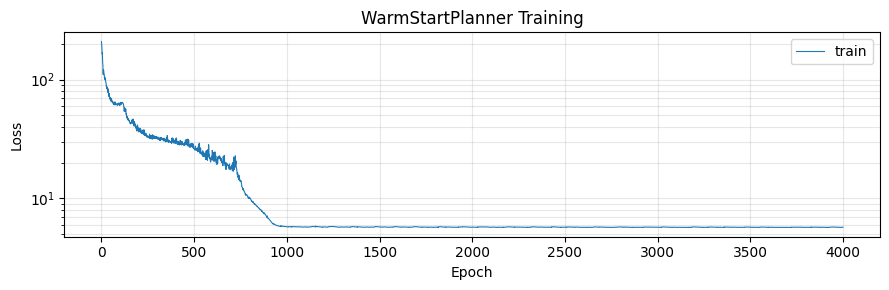

Model saved: models/warm_start_planner_overfit__v2_1_sample.pt


In [10]:
# ---------- WarmStartPlanner SSL Training ----------
# Overfitting: 1 sample verification
print("Starting training...")
    
model_1_sample, history_1_sample = train(
    # Paths
    train_dataset       = "data/dataset_overfit_v2_1_sample.pt",
    val_dataset         = None,
        
    # Configuration
    T                   = 50,
    C                   = 10,
        
    # Pre-trained encoders
    env_encoder_path    = "data/env_encoder_overfit_v2.pt",
    state_encoder_path  = "data/state_encoder_overfit_v2.pt",
    freeze_encoders     = False,
        
    # Parameters
    n_epochs            = 4000,
    batch_size          = 1,
    lr                  = 5e-4,
        
    # Loss weights
    w_coll              = 300.0,
    w_joints            = 0.1,
    w_smooth            = 0.2,
    w_spacing           = 1.0,
    w_explore           = 5.0,
        
    # Collision parameters
    explore_threshold   = 0.5,
    collision_eps       = 0.20,
    dt                  = 0.1,
        
    # Monitoring and Hardware
    log_every           = 200,
    device              = "cuda",
    save_path           = "models/warm_start_planner_overfit__v2_1_sample.pt",
)

In [ ]:
# ---------- Trajectory Visualization ----------
print("Loading model and dataset...")

# Load the model
model_1_sample = torch.load("models/warm_start_planner_overfit__v2_1_sample.pt", weights_only=False)
    
# Launch the visualizator
browse_trajectories(
    model     = model_1_sample,
    dataset   = "data/dataset_overfit_v2_1_sample.pt",
    save_name = "overfit_1_sample_working"
)

Loading model and dataset...
